## IMPORTS

In [3]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

## LOAD DATA

In [4]:
df = pd.read_csv('churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## CLEANING

In [5]:
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

## SELECT FEATURES

In [7]:
df = df[['tenure','MonthlyCharges','TotalCharges','Contract','PaymentMethod','Churn']]

## ENCODING

In [9]:
le = LabelEncoder()

df['Contract'] = le.fit_transform(df['Contract'])
df['PaymentMethod'] = le.fit_transform(df['PaymentMethod'])
df['Churn'] = le.fit_transform(df['Churn'])

## SPLIT

In [10]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## TRAIN MODEL

In [12]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## EVALUATION

In [13]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7512437810945274

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84      1033
           1       0.54      0.43      0.48       374

    accuracy                           0.75      1407
   macro avg       0.67      0.65      0.66      1407
weighted avg       0.74      0.75      0.74      1407



## CONFUSION MATRIX

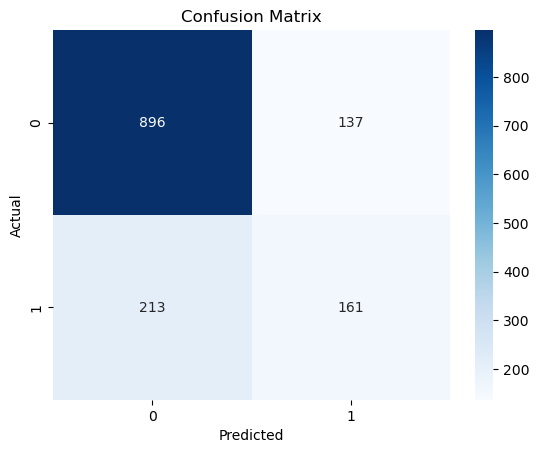

In [14]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## FEATURE IMPORTANCE

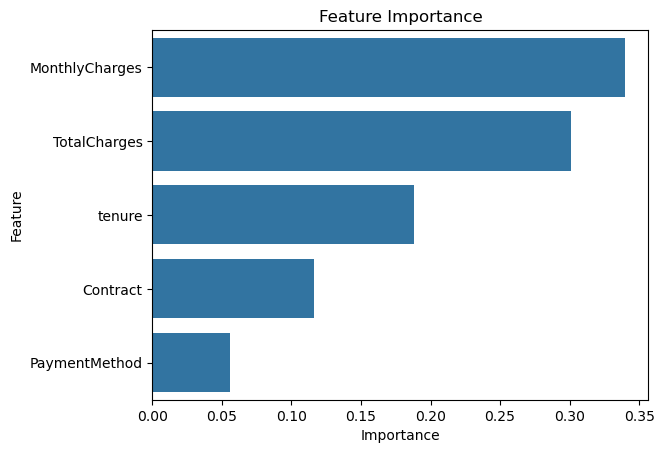

In [15]:
importance = model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance")
plt.show()

## SAVE MODEL

In [16]:
pickle.dump(model, open('churn_model.pkl', 'wb'))

# FRONTEND

In [29]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.


In [30]:
import gradio as gr
import pandas as pd
import pickle

model = pickle.load(open('churn_model.pkl', 'rb'))

In [31]:
def predict_churn(tenure, monthly, total, contract, payment):
    
    contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
    payment_map = {"Electronic check": 0, "Mailed check": 1, "Bank transfer": 2, "Credit card": 3}
    
    input_data = pd.DataFrame([[tenure, monthly, total,
                                contract_map[contract],
                                payment_map[payment]]],
                              columns=['tenure','MonthlyCharges','TotalCharges','Contract','PaymentMethod'])
    
    prediction = model.predict(input_data)
    probability = model.predict_proba(input_data)
    
    if prediction[0] == 1:
        return f"❌ Customer likely to CHURN\nConfidence: {probability}"
    else:
        return f"✅ Customer likely to STAY\nConfidence: {probability}"

In [32]:
interface = gr.Interface(
    fn=predict_churn,
    inputs=[
        gr.Slider(0, 72, label="Tenure (months)"),
        gr.Number(label="Monthly Charges"),
        gr.Number(label="Total Charges"),
        gr.Dropdown(["Month-to-month", "One year", "Two year"], label="Contract"),
        gr.Dropdown(["Electronic check", "Mailed check", "Bank transfer", "Credit card"], label="Payment Method")
    ],
    outputs="text",
    title="📊 Customer Churn Prediction System",
    description="Enter customer details to predict churn"
)

In [33]:
interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
